# Gaussian beams as local wave packets

This notebook makes one slide-ready figure that explains how Gaussian beams are propagated in TemGym. The goal is to keep the story visual: each beam is a small wave packet carried by a central ray, and each optical element only has to be understood locally around that packet.

The same update is used for a lens, a soft aperture, and a biprism. Each object contributes a small action `dS`; TemGym expands that action near the beam centre and uses the coefficients to update the packet in one step.

In [1]:
import os

os.environ["JAX_ENABLE_X64"] = "1"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import patheffects as pe
from matplotlib.patches import Circle, FancyArrowPatch, Rectangle

from temgym_core.components import Lens, PhaseBiprism, SigmoidAperture
from temgym_core.gaussian import apply_action_delta, make_gaussian, taylor_expand

jax.config.update("jax_enable_x64", True)

# Save beside this notebook whether Jupyter is launched from the repo root
# or from examples/gaussians.
if (Path.cwd() / "examples" / "gaussians").exists():
    NOTEBOOK_DIR = Path.cwd() / "examples" / "gaussians"
else:
    NOTEBOOK_DIR = Path.cwd()

FIG_DIR = NOTEBOOK_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 14,
    "axes.titlesize": 18,
    "axes.labelsize": 15,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

## The update rule in words

For a beam centred at position `r0`, we write nearby positions as `r0 + Delta r`. The optical element is replaced locally by a quadratic model,

`dS(r0 + Delta r) approx dS0 + dS1 . Delta r + 1/2 Delta r^T dS2 Delta r`.

The three terms have direct physical roles. `dS0` changes the phase and amplitude at the beam centre. `dS1` steers the central ray. `dS2` changes the local curvature of the wave packet, so it can focus, defocus, or change width. A soft aperture uses `log_transmission`, which makes absorption look like the imaginary part of the same action.

In [2]:
def _as_float_array(x):
    return np.asarray(x, dtype=float)


def line_action_profile(component, x_um, y0_um=0.0, *, k=None, ray=None):
    xy = jnp.column_stack([jnp.asarray(x_um) * 1e-6, jnp.full_like(jnp.asarray(x_um), y0_um * 1e-6)])
    if hasattr(component, "complex_action") and k is not None:
        values = jax.vmap(lambda p: component.complex_action(p, k))(xy)
    else:
        phase = jax.vmap(component.phase_shift)(xy)
        log_t = jax.vmap(component.log_transmission)(xy)
        if k is None:
            values = phase + 1j * 0.0
        else:
            values = phase - 1j * (jnp.logaddexp(log_t, -50.0) / k)
    return np.asarray(values)


def action_taylor_line(component, ray, x_um):
    xy_ref = ray.r_xy
    k = ray.k

    dS0, dS1, dS2 = taylor_expand(component.complex_action, xy_ref, k)
    dx = jnp.asarray(x_um) * 1e-6 - xy_ref[0]
    dy = jnp.zeros_like(dx) - xy_ref[1]
    d = jnp.column_stack([dx, dy])
    approx = dS0 + d @ dS1 + 0.5 * jnp.einsum("...i,ij,...j->...", d, dS2, d)
    exact = jax.vmap(lambda p: component.complex_action(p, k))(jnp.column_stack([jnp.asarray(x_um) * 1e-6, jnp.zeros_like(jnp.asarray(x_um))]))
    tangent = dS0 + d @ dS1
    return np.asarray(exact), np.asarray(tangent), np.asarray(approx), (dS0, dS1, dS2)


def gaussian_envelope(x, centre, waist):
    return np.exp(-((x - centre) ** 2) / (2 * waist ** 2))


def annotate_panel(ax, label):
    ax.text(
        -0.06,
        1.06,
        label,
        transform=ax.transAxes,
        fontsize=18,
        fontweight="bold",
        va="top",
        ha="left",
        path_effects=[pe.withStroke(linewidth=3, foreground="white")],
    )


def draw_arrow(ax, start, end, color="#2f6f9f", mutation_scale=14, lw=1.8, **kwargs):
    patch = FancyArrowPatch(
        start,
        end,
        arrowstyle="-|>",
        mutation_scale=mutation_scale,
        linewidth=lw,
        color=color,
        shrinkA=0,
        shrinkB=0,
        **kwargs,
    )
    ax.add_patch(patch)
    return patch


def draw_box(ax, xy, text, width=0.22, height=0.16, fc="#f7f7f2", ec="#333333", fontsize=14):
    x, y = xy
    rect = Rectangle((x, y), width, height, facecolor=fc, edgecolor=ec, linewidth=1.2)
    ax.add_patch(rect)
    ax.text(x + width / 2, y + height / 2, text, ha="center", va="center", fontsize=fontsize)
    return rect


def save_figure(fig, stem):
    png_path = FIG_DIR / f"{stem}.png"
    svg_path = FIG_DIR / f"{stem}.svg"
    fig.savefig(png_path, bbox_inches="tight", facecolor="white")
    fig.savefig(svg_path, bbox_inches="tight", facecolor="white")
    print(f"Saved {png_path}")
    print(f"Saved {svg_path}")
    return png_path, svg_path


## Build the objects used in the figure

The examples below use the same public component interface as the simulation code. The numbers are chosen for readable sketches, not for a full microscope design.

In [3]:
voltage = 200e3
beam = make_gaussian(
    x=0.35e-6,
    y=0.0,
    dx=0.0,
    dy=0.0,
    voltage=voltage,
    waist_x=0.28e-6,
    waist_y=0.28e-6,
)

lens = Lens(z=0.0, focal_length=4.0e-6)
aperture = SigmoidAperture(z=0.0, radius=0.85e-6, edge_width=0.18e-6, sharpness=7.0, t_low=0.08, t_high=1.0)
biprism = PhaseBiprism(z=0.0, strength=0.18, width=0.22e-6, sharpness=22.0)

# Demonstrate that the real code computes the three local coefficients and applies one update.
examples = {"Lens": lens, "Aperture": aperture, "Biprism": biprism}
rows = []
for name, component in examples.items():
    dS0, dS1, dS2 = taylor_expand(component.complex_action, beam.r_xy, beam.k)
    r_new, d_new, amp_new, path_new, q_new = apply_action_delta(beam, dS0, dS1, dS2)
    rows.append((name, np.asarray(r_new) * 1e6, np.asarray(d_new), float(np.abs(amp_new))))

for name, r_new_um, d_new, amp_abs in rows:
    print(f"{name:8s}: centre -> ({r_new_um[0]: .3f}, {r_new_um[1]: .3f}) um, "
          f"slope -> ({d_new[0]: .3e}, {d_new[1]: .3e}), |amp| -> {amp_abs:.3f}")

Lens    : centre -> ( 0.350,  0.000) um, slope -> (-8.750e-02,  0.000e+00), |amp| -> 1.000
Aperture: centre -> ( 0.350,  0.000) um, slope -> ( 0.000e+00,  0.000e+00), |amp| -> 1.000
Biprism : centre -> ( 0.350,  0.000) um, slope -> (-1.800e-01,  0.000e+00), |amp| -> 0.500


## Separate slide figures

The four ideas are exported as separate figures so each can sit on its own slide without crowding. The figures use the same beam and component definitions above.

### Figure 1: A Gaussian beam as a local wave packet

This figure introduces the object being propagated. The beam is represented by a centre position, a slope for the central ray, and a local width/curvature.

Saved /home/dl277493/Documents/Code/TemGymCore/examples/gaussians/figures/gaussian_beam_packet.png
Saved /home/dl277493/Documents/Code/TemGymCore/examples/gaussians/figures/gaussian_beam_packet.svg


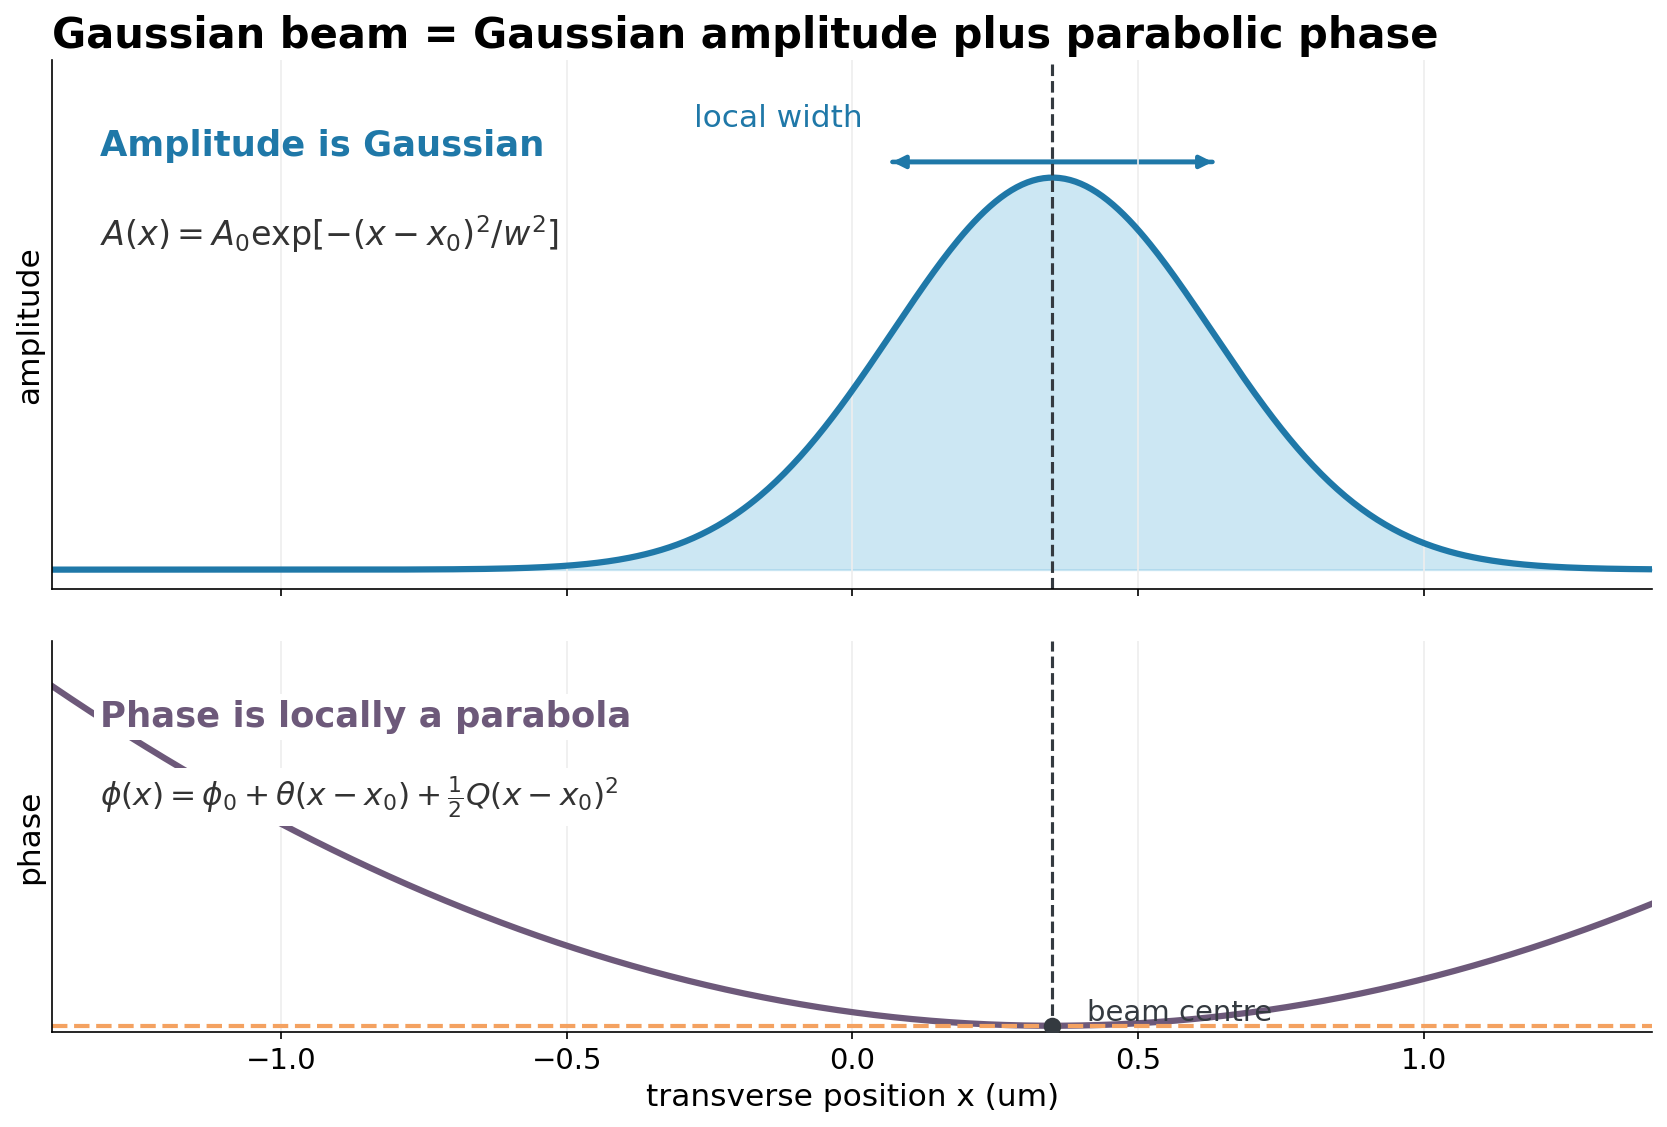

In [4]:
x_um = np.linspace(-1.4, 1.4, 600)
x_m = x_um * 1e-6
beam_centre_um = float(np.asarray(beam.x)) * 1e6
beam_waist_um = 0.28

envelope = gaussian_envelope(x_um, beam_centre_um, beam_waist_um)
phase_parabola = 0.70 * (x_um - beam_centre_um) ** 2 - 0.08
phase_tangent = np.zeros_like(x_um) - 0.08

fig, (ax_amp, ax_phase) = plt.subplots(
    2,
    1,
    figsize=(11.0, 7.4),
    sharex=True,
    gridspec_kw={"height_ratios": [1.15, 0.85], "hspace": 0.08},
    constrained_layout=True,
)

# Amplitude: the local packet has a Gaussian envelope.
ax_amp.fill_between(x_um, 0, envelope, color="#8ecae6", alpha=0.45)
ax_amp.plot(x_um, envelope, color="#1f78a8", lw=3.0)
ax_amp.axvline(beam_centre_um, color="#343a40", lw=1.5, ls="--")
ax_amp.text(0.03, 0.82, "Amplitude is Gaussian", transform=ax_amp.transAxes, fontsize=17, fontweight="bold", color="#1f78a8")
ax_amp.text(0.03, 0.65, r"$A(x) = A_0\exp[-(x-x_0)^2 / w^2]$", transform=ax_amp.transAxes, fontsize=16, color="#333333")

# Width marker.
ax_amp.text(beam_centre_um - 0.48, 1.13, "local width", color="#1f78a8", fontsize=15, ha="center")
draw_arrow(ax_amp, (beam_centre_um - beam_waist_um, 1.04), (beam_centre_um + beam_waist_um, 1.04), color="#1f78a8", mutation_scale=12, lw=2.2)
draw_arrow(ax_amp, (beam_centre_um + beam_waist_um, 1.04), (beam_centre_um - beam_waist_um, 1.04), color="#1f78a8", mutation_scale=12, lw=2.2)

ax_amp.set_title("Gaussian beam = Gaussian amplitude plus parabolic phase", loc="left", fontweight="bold", fontsize=20)
ax_amp.set_ylabel("amplitude", fontsize=15)
ax_amp.set_xlim(x_um.min(), x_um.max())
ax_amp.set_ylim(-0.05, 1.30)
ax_amp.set_yticks([])
ax_amp.grid(axis="x", color="#eeeeee", linewidth=0.8)

# Phase: a Gaussian beam keeps only the local quadratic phase.
ax_phase.plot(x_um, phase_parabola, color="#6d597a", lw=3.0)
ax_phase.plot(x_um, phase_tangent, color="#f4a261", lw=2.0, ls="--")
ax_phase.axvline(beam_centre_um, color="#343a40", lw=1.5, ls="--")
ax_phase.scatter([beam_centre_um], [-0.08], s=55, color="#343a40", zorder=5)
ax_phase.text(
    0.03,
    0.78,
    "Phase is locally a parabola",
    transform=ax_phase.transAxes,
    fontsize=17,
    fontweight="bold",
    color="#6d597a",
    bbox={"facecolor": "white", "edgecolor": "none", "alpha": 1.0, "pad": 3},
)
ax_phase.text(
    0.03,
    0.58,
    r"$\phi(x) = \phi_0 + \theta(x-x_0) + \frac{1}{2}Q(x-x_0)^2$",
    transform=ax_phase.transAxes,
    fontsize=15,
    color="#333333",
    bbox={"facecolor": "white", "edgecolor": "none", "alpha": 1.0, "pad": 3},
)
ax_phase.text(beam_centre_um + 0.06, -0.045, "beam centre", fontsize=14, color="#343a40")
ax_phase.set_xlabel("transverse position x (um)", fontsize=15)
ax_phase.set_ylabel("phase", fontsize=15)
ax_phase.set_ylim(-0.12, 2.35)
ax_phase.set_yticks([])
ax_phase.grid(axis="x", color="#eeeeee", linewidth=0.8)

save_figure(fig, "gaussian_beam_packet")
plt.show()

### Figure 2: Taylor expansion of the optical action

This figure shows the local approximation used at each component. The exact action is only needed near the beam centre, where its value, slope, and curvature are enough to update the Gaussian packet.

Saved /home/dl277493/Documents/Code/TemGymCore/examples/gaussians/figures/local_action_taylor_expansion.png
Saved /home/dl277493/Documents/Code/TemGymCore/examples/gaussians/figures/local_action_taylor_expansion.svg


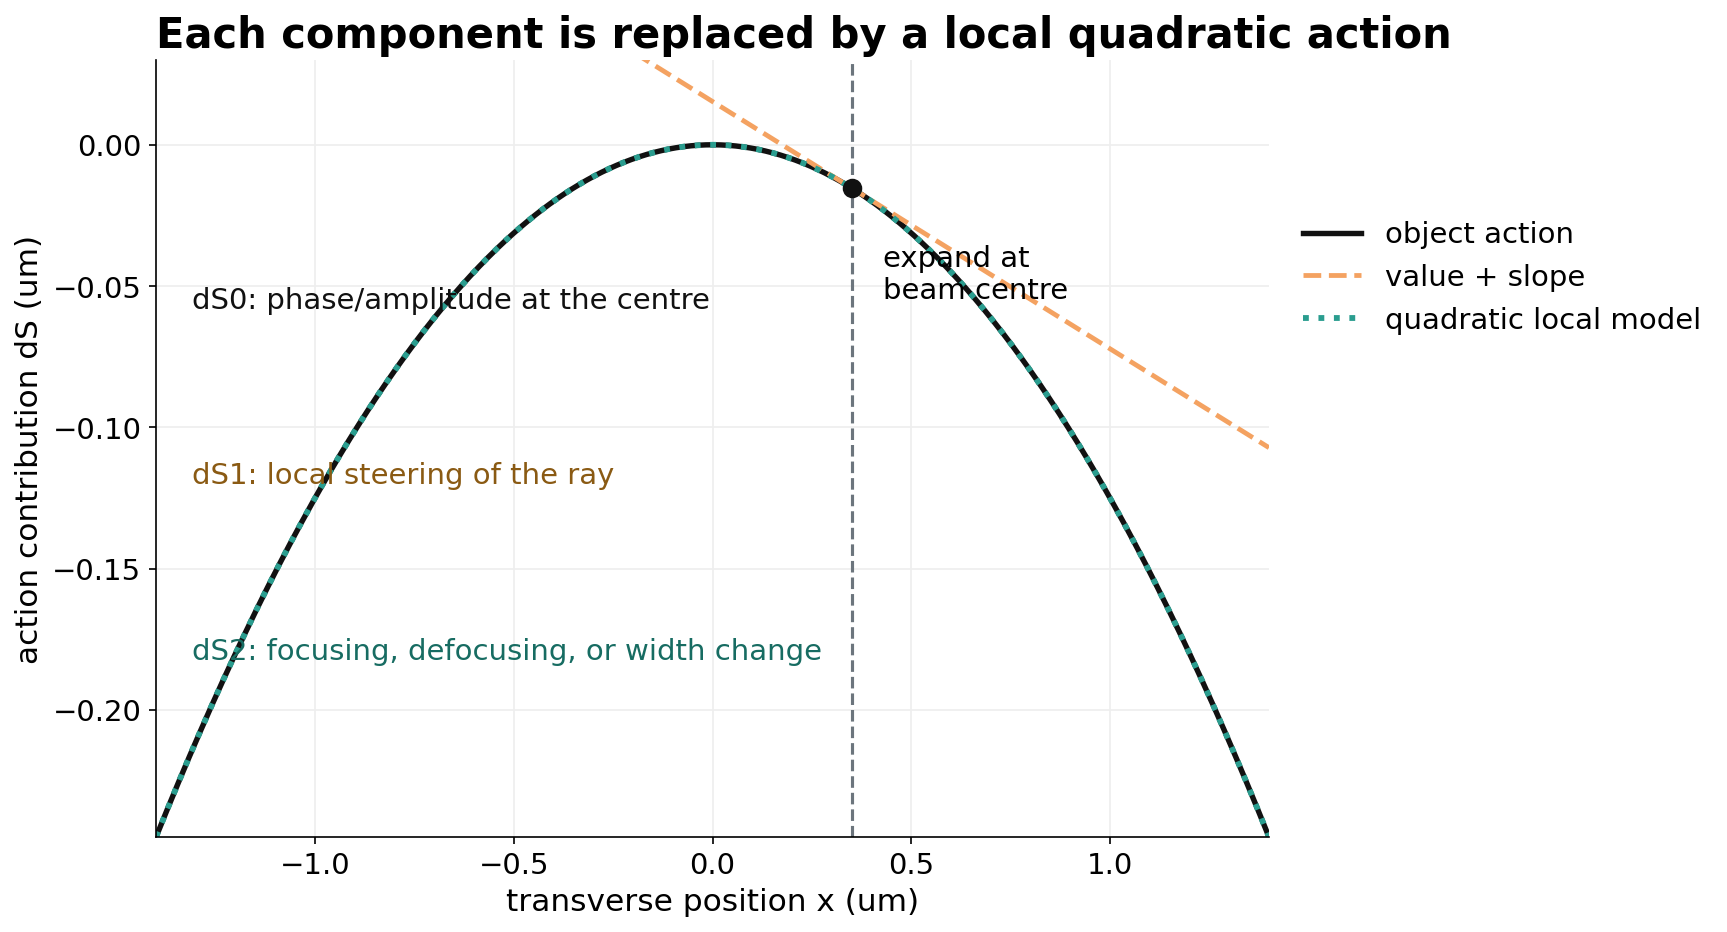

In [5]:
exact, tangent, quad, coeffs = action_taylor_line(lens, beam, x_um)
scale_action = 1e6  # display small optical-path action in micrometres.

fig, ax = plt.subplots(figsize=(11.4, 6.1), constrained_layout=True)
ax.plot(x_um, scale_action * np.real(exact), color="#111111", lw=2.6, label="object action")
ax.plot(x_um, scale_action * np.real(tangent), color="#f4a261", lw=2.3, ls="--", label="value + slope")
ax.plot(x_um, scale_action * np.real(quad), color="#2a9d8f", lw=2.8, ls=":", label="quadratic local model")
ax.axvline(beam_centre_um, color="#6c757d", lw=1.5, ls="--")
ax.scatter([beam_centre_um], [scale_action * np.real(coeffs[0])], s=70, color="#111111", zorder=5)

ax.text(beam_centre_um + 0.08, scale_action * np.real(coeffs[0]) - 0.020, "expand at\nbeam centre", fontsize=14, va="top")
ax.text(-1.31, -0.058, "dS0: phase/amplitude at the centre", fontsize=14, color="#111111")
ax.text(-1.31, -0.120, "dS1: local steering of the ray", fontsize=14, color="#8a5a13")
ax.text(-1.31, -0.182, "dS2: focusing, defocusing, or width change", fontsize=14, color="#176c62")

ax.set_title("Each component is replaced by a local quadratic action", loc="left", fontweight="bold", fontsize=20)
ax.set_xlabel("transverse position x (um)", fontsize=15)
ax.set_ylabel("action contribution dS (um)", fontsize=15)
ax.set_xlim(x_um.min(), x_um.max())
ax.set_ylim(-0.245, 0.030)
ax.legend(frameon=False, loc="center left", bbox_to_anchor=(1.02, 0.72), fontsize=14, borderaxespad=0.0)
ax.grid(color="#eeeeee", linewidth=0.8)

save_figure(fig, "local_action_taylor_expansion")
plt.show()

### Figure 3: Lens, aperture, and biprism use the same coefficient extraction

The physical objects look different, but each provides a local phase and/or transmission profile. The Gaussian update only needs the local coefficients around the beam centre.

Saved /home/dl277493/Documents/Code/TemGymCore/examples/gaussians/figures/same_coefficients_lens_aperture_biprism.png
Saved /home/dl277493/Documents/Code/TemGymCore/examples/gaussians/figures/same_coefficients_lens_aperture_biprism.svg


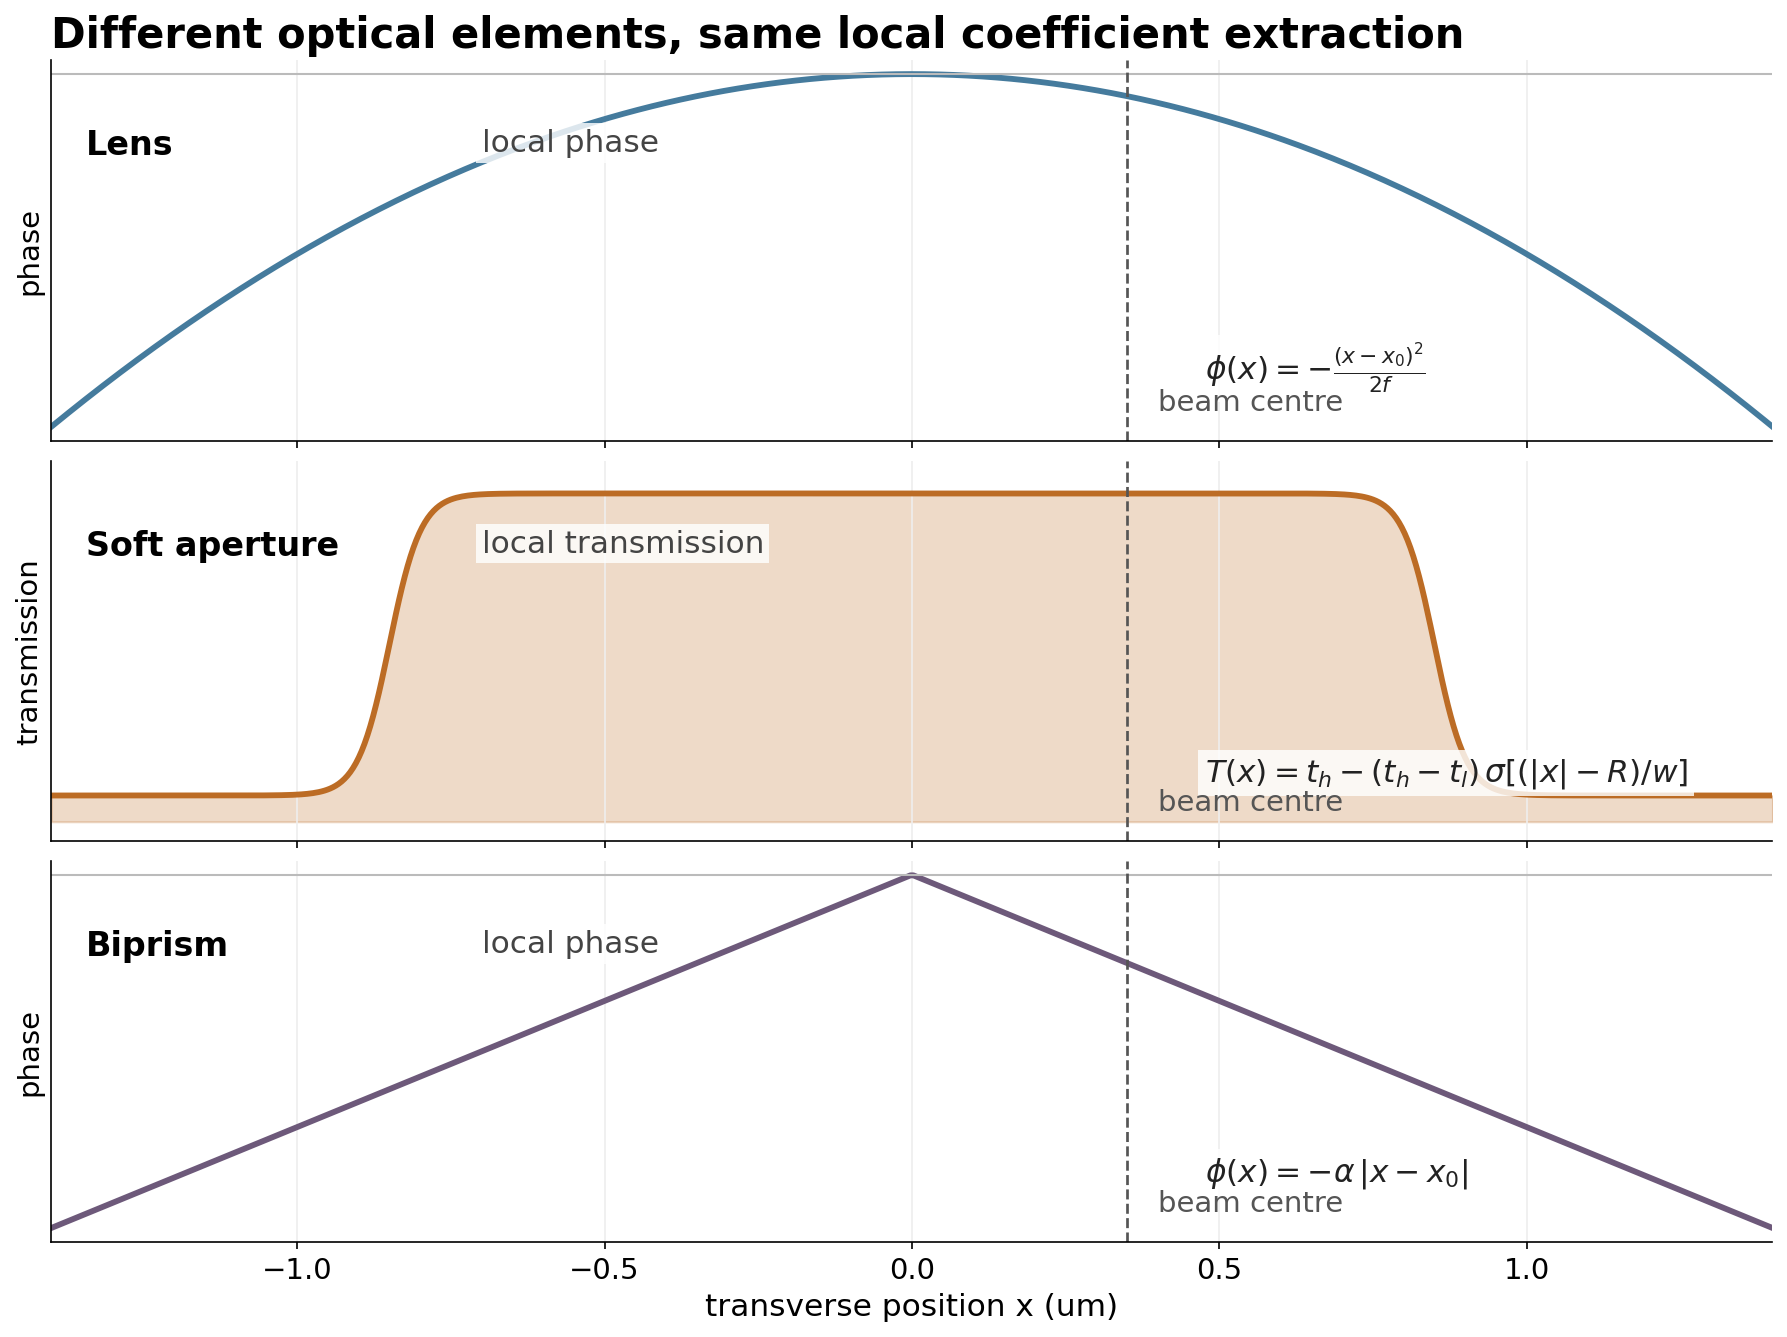

In [6]:
component_specs = [
    ("Lens", lens, "local phase", r"$\phi(x)=-\frac{(x-x_0)^2}{2f}$", "#457b9d"),
    ("Soft aperture", aperture, "local transmission", r"$T(x)=t_h-(t_h-t_l)\,\sigma[(|x|-R)/w]$", "#bc6c25"),
    ("Biprism", biprism, "local phase", r"$\phi(x)=-\alpha\,|x-x_0|$", "#6d597a"),
]

fig, axs = plt.subplots(3, 1, figsize=(11.8, 8.8), sharex=True, constrained_layout=True)
for ax, (name, component, quantity, equation, color) in zip(axs, component_specs):
    values = line_action_profile(component, x_um, k=beam.k)
    if name == "Soft aperture":
        coords = jnp.column_stack([jnp.asarray(x_m), jnp.zeros_like(jnp.asarray(x_m))])
        profile = np.exp(np.real(jax.vmap(component.log_transmission)(coords)))
        ax.fill_between(x_um, 0, profile, color=color, alpha=0.25)
        ax.plot(x_um, profile, color=color, lw=2.8)
        ax.set_ylim(-0.06, 1.10)
        ax.set_ylabel("transmission", fontsize=14)
        eq_y = 0.16
    else:
        profile = np.real(values)
        ax.plot(x_um, profile, color=color, lw=2.8)
        ax.axhline(0, color="#bbbbbb", lw=1.0)
        pad = 0.04 * (profile.max() - profile.min() + 1e-12)
        ax.set_ylim(profile.min() - pad, profile.max() + pad)
        ax.set_ylabel("phase", fontsize=14)
        eq_y = 0.16

    ax.axvline(beam_centre_um, color="#555555", lw=1.3, ls="--")
    ax.text(0.02, 0.82, name, transform=ax.transAxes, fontsize=16, fontweight="bold", va="top")
    ax.text(
        0.25,
        0.82,
        quantity,
        transform=ax.transAxes,
        fontsize=15,
        color="#444444",
        va="top",
        bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.82, "pad": 2.5},
    )
    ax.text(
        0.67,
        eq_y,
        equation,
        transform=ax.transAxes,
        fontsize=15,
        color="#222222",
        bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.82, "pad": 3},
    )
    ax.text(beam_centre_um + 0.05, 0.08, "beam centre", transform=ax.get_xaxis_transform(), fontsize=14, color="#555555")
    ax.set_yticks([])
    ax.grid(axis="x", color="#eeeeee", linewidth=0.8)

axs[0].set_title("Different optical elements, same local coefficient extraction", loc="left", fontweight="bold", fontsize=20)
axs[-1].set_xlabel("transverse position x (um)", fontsize=15)
axs[-1].set_xlim(x_um.min(), x_um.max())

save_figure(fig, "same_coefficients_lens_aperture_biprism")
plt.show()

### Figure 4: One-step Gaussian update

Once `dS0`, `dS1`, and `dS2` are known, the packet centre, slope, amplitude, path length, and curvature are updated in one component call.

Saved /home/dl277493/Documents/Code/TemGymCore/examples/gaussians/figures/one_step_gaussian_update.png
Saved /home/dl277493/Documents/Code/TemGymCore/examples/gaussians/figures/one_step_gaussian_update.svg


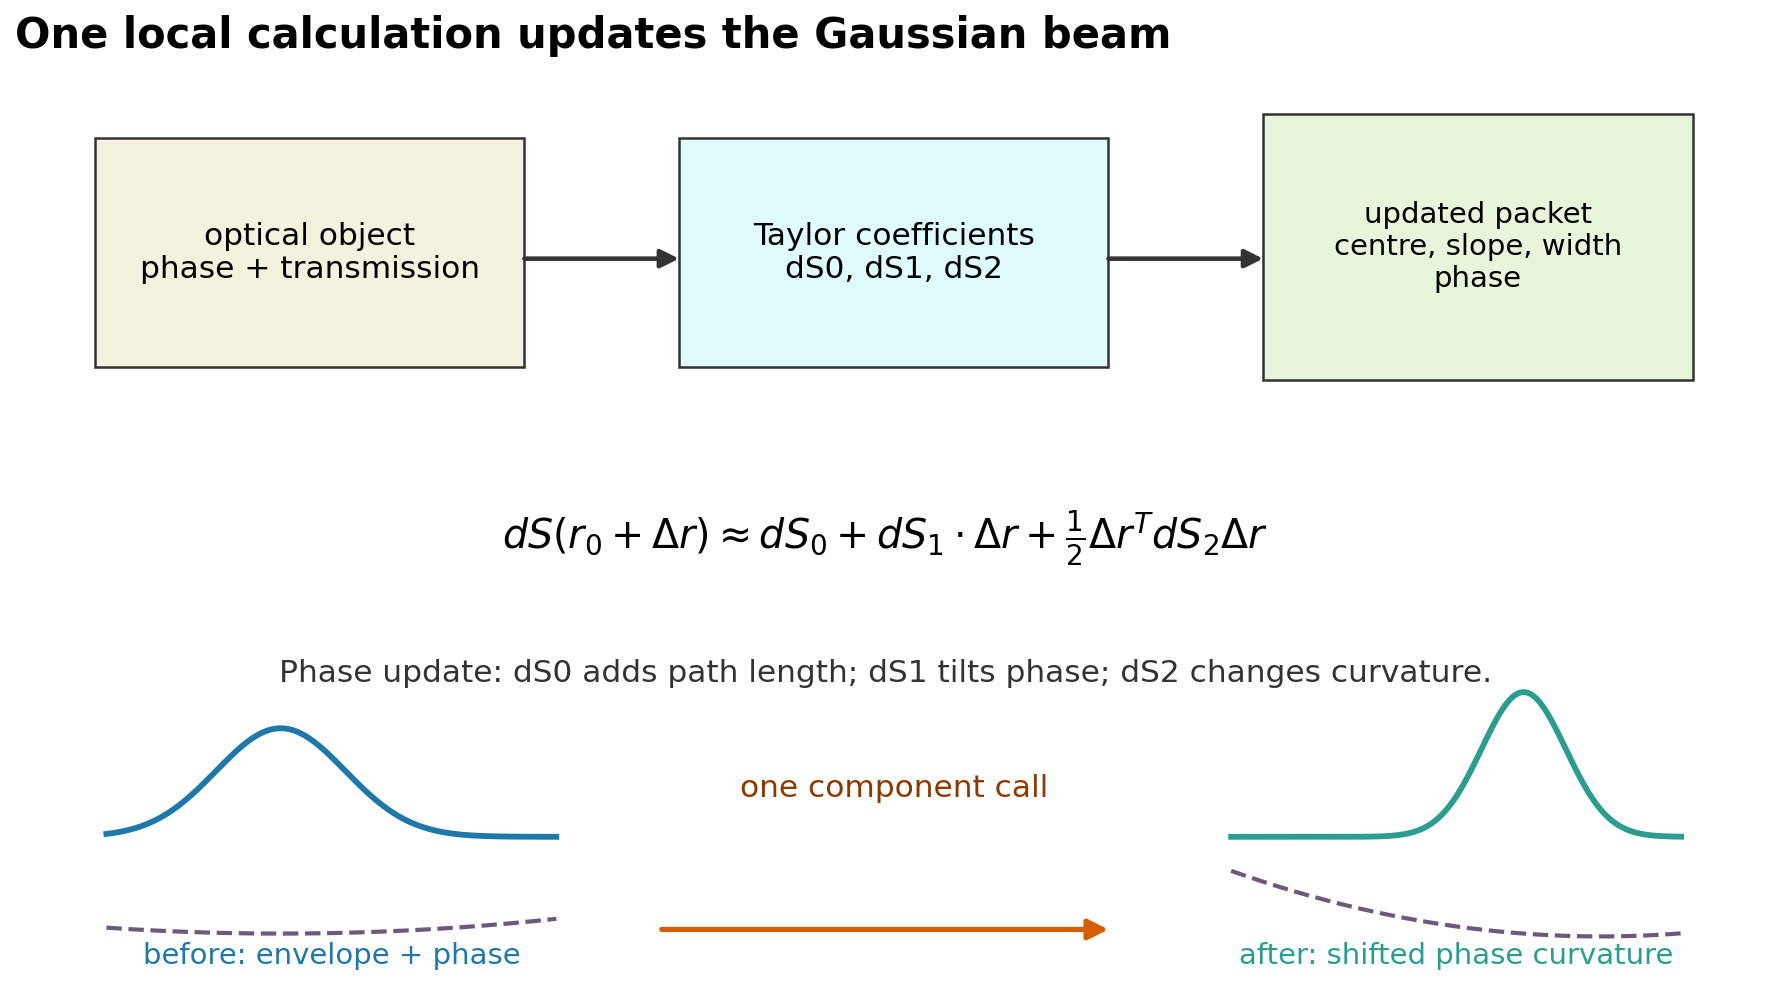

In [7]:
fig, ax = plt.subplots(figsize=(11.8, 6.5), constrained_layout=True)
ax.set_axis_off()
ax.set_title("One local calculation updates the Gaussian beam", loc="left", fontweight="bold", fontsize=20, pad=12)

# Main flow boxes.
draw_box(ax, (0.04, 0.62), "optical object\nphase + transmission", width=0.25, height=0.19, fc="#f4f1de", fontsize=15)
draw_box(ax, (0.38, 0.62), "Taylor coefficients\ndS0, dS1, dS2", width=0.25, height=0.19, fc="#e0fbfc", fontsize=15)
draw_box(ax, (0.72, 0.61), "updated packet\ncentre, slope, width\nphase", width=0.25, height=0.22, fc="#e9f5db", fontsize=14)
draw_arrow(ax, (0.29, 0.71), (0.38, 0.71), color="#333333", mutation_scale=18, lw=2.2)
draw_arrow(ax, (0.63, 0.71), (0.72, 0.71), color="#333333", mutation_scale=18, lw=2.2)

# Formula and short explanation.
ax.text(
    0.50,
    0.47,
    r"$dS(r_0 + \Delta r) \approx dS_0 + dS_1 \cdot \Delta r + \frac{1}{2}\Delta r^T dS_2\Delta r$",
    fontsize=19,
    ha="center",
)
ax.text(
    0.50,
    0.36,
    "Phase update: dS0 adds path length; dS1 tilts phase; dS2 changes curvature.",
    fontsize=15,
    ha="center",
    color="#333333",
)

# Before/after packet sketch.
sketch_x = np.linspace(-0.8, 0.8, 200)
before = 0.12 * gaussian_envelope(sketch_x, -0.18, 0.23) + 0.155
after = 0.16 * gaussian_envelope(sketch_x, 0.24, 0.15) + 0.155
before_phase = 0.048 + 0.017 * (sketch_x + 0.18) ** 2
after_phase = 0.048 + 0.042 * (sketch_x - 0.24) ** 2 - 0.023 * (sketch_x - 0.24)
ax.plot(0.18 + 0.16 * sketch_x, before, color="#1f78a8", lw=2.8, transform=ax.transAxes, clip_on=False)
ax.plot(0.82 + 0.16 * sketch_x, after, color="#2a9d8f", lw=2.8, transform=ax.transAxes, clip_on=False)
ax.plot(0.18 + 0.16 * sketch_x, before_phase, color="#6d597a", lw=2.0, ls="--", transform=ax.transAxes, clip_on=False)
ax.plot(0.82 + 0.16 * sketch_x, after_phase, color="#6d597a", lw=2.0, ls="--", transform=ax.transAxes, clip_on=False)
draw_arrow(ax, (0.37, 0.155), (0.63, 0.155), color="#d55e00", mutation_scale=20, lw=2.5)
ax.text(0.50, 0.20, "one component call", transform=ax.transAxes, ha="center", fontsize=15, color="#8a3a00")
ax.text(0.18, 0.015, "before: envelope + phase", transform=ax.transAxes, ha="center", fontsize=14, color="#1f78a8")
ax.text(0.82, 0.015, "after: shifted phase curvature", transform=ax.transAxes, ha="center", fontsize=14, color="#2a9d8f")

save_figure(fig, "one_step_gaussian_update")
plt.show()

## Speaking notes

A useful way to present the slide is to move from left to right. First, the beam is not a full image calculation at every surface; it is a compact local packet with a centre, direction, and curvature. Second, each optical element is only sampled locally around that packet. Third, the same three Taylor coefficients explain different physical effects. In practice, this means that once an object provides a phase shift and, if needed, a log-transmission, TemGym can update the Gaussian beam in one component call.